In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import *

# code to submit

In [54]:
def contraction_solve(g_func, a, b, lamb, f0_func, tol=1e-6, max_iter = 100):
    # discretize x for evaluation
    x_vals = np.linspace(a, b, 100)
    f_old = f0_func(x_vals)

    for iteration in range(max_iter):
        f_new_vals = []
        for x in x_vals:
            # define the integrand: K(x, y) * f_old(y)
            # evaluate f_old at y using np.interp
            def integrand(y):
                fy = np.interp(y, x_vals, f_old)
                return 1 / (1 + (x-y)**2 ) * fy

            integral = quad(integrand, a, b)[0]
            f_new_vals.append(g_func(x) + lamb * integral)

        f_new_vals = np.array(f_new_vals)
        plt.plot(x_vals, f_new_vals, label = rf'$T^{iteration}$(x)')

        # check for convergence using the supremum norm (max absolute difference)
        diff = np.max(np.abs(f_new_vals - f_old))
        if diff < tol:
            plt.plot(x_vals, g_func(x_vals), 'k--', label = r'$\sin(2\pi x)$')
            plt.plot(x_vals, f0_func(x_vals), 'r--', label = 'f(x)')
            plt.xlabel('x')
            plt.ylabel(r'$T^n(f)$')
            plt.title(rf"$T^n(f)$ for $\lambda = {lamb}$")
            plt.legend()
            plt.show()
            print(f"Converged in {iteration} iterations")
            return x_vals, f_new_vals

        f_old = f_new_vals

    plt.plot(x_vals, g_func(x_vals), 'k--', label = r'$\sin(2\pi x)$')
    plt.plot(x_vals, f0_func(x_vals), 'r--', label = 'f(x)')
    plt.xlabel('x')
    plt.ylabel(r'$T^n(f)$')
    plt.title(rf"$T^n(f)$ for $\lambda = {lamb}$")
    # plt.legend()
    plt.show()

    print("Max iterations reached without full convergence.")
    return x_vals, f_old

/tmp/ipykernel_8978/1522594962.py:15: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral = quad(integrand, a, b)[0]


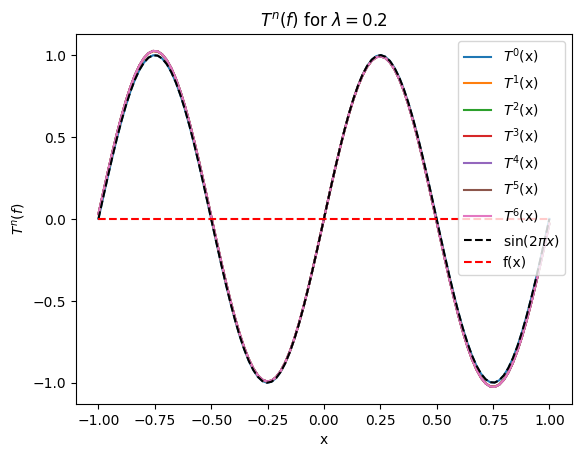

Converged in 6 iterations


In [39]:
g = lambda x: np.sin(2*np.pi*x)
K = lambda x, y: 1 / (1 + (x-y)**2 )
f0 = lambda x: np.zeros_like(x)

x_grid, solution = contraction_solve(g, -1, 1, lamb = 0.2, f0_func = f0)


/tmp/ipykernel_8978/1522594962.py:15: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral = quad(integrand, a, b)[0]


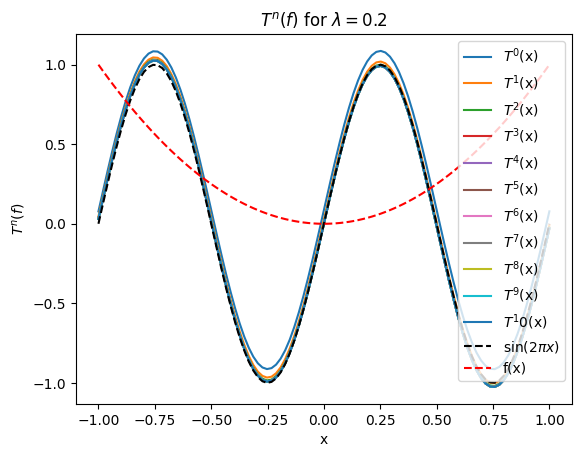

Converged in 10 iterations


In [40]:
g = lambda x: np.sin(2*np.pi*x)
K = lambda x, y: 1 / (1 + (x-y)**2 )
f0 = lambda x: x**2

x_grid, solution = contraction_solve(g, -1, 1, lamb = 0.2, f0_func = f0)

/tmp/ipykernel_8978/1250303295.py:15: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral = quad(integrand, a, b)[0]


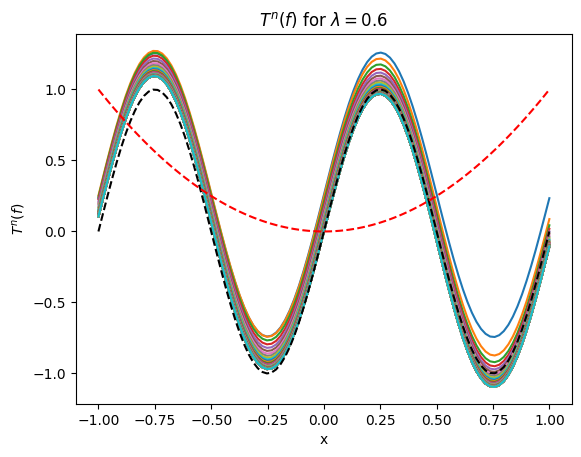

Converged in 69 iterations


In [55]:
g = lambda x: np.sin(2*np.pi*x)
K = lambda x, y: 1 / (1 + (x-y)**2 )
f0 = lambda x: x**2

x_grid, solution = contraction_solve(g, -1, 1, lamb = 0.6, f0_func = f0)

/tmp/ipykernel_8978/2331196572.py:15: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral = quad(integrand, a, b)[0]
/tmp/ipykernel_8978/2331196572.py:15: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral = quad(integrand, a, b)[0]


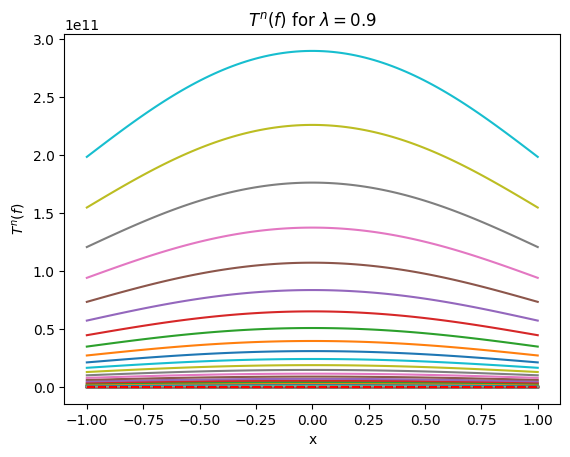

Max iterations reached without full convergence.


In [45]:
g = lambda x: np.sin(2*np.pi*x)
K = lambda x, y: 1 / (1 + (x-y)**2 )
f0 = lambda x: x**2

x_grid, solution = contraction_solve(g, -1, 1, lamb = 0.9, f0_func = f0)

/tmp/ipykernel_8978/2331196572.py:15: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral = quad(integrand, a, b)[0]
/tmp/ipykernel_8978/2331196572.py:15: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral = quad(integrand, a, b)[0]


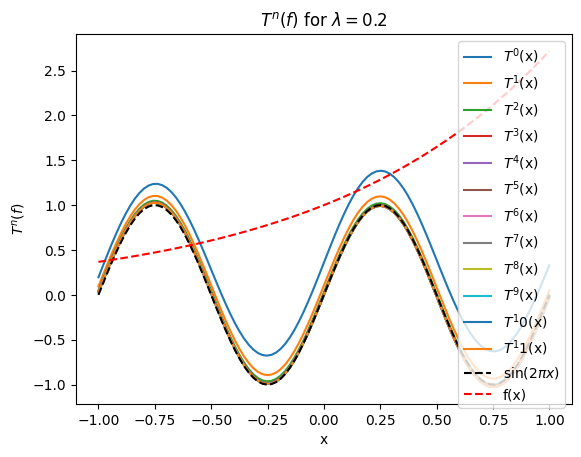

Converged in 11 iterations


In [49]:
g = lambda x: np.sin(2*np.pi*x)
K = lambda x, y: 1 / (1 + (x-y)**2 )
f0 = lambda x: np.exp(x)

x_grid, solution = contraction_solve(g, -1, 1, lamb = 0.2, f0_func = f0)


/tmp/ipykernel_8978/2331196572.py:15: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral = quad(integrand, a, b)[0]
/tmp/ipykernel_8978/2331196572.py:15: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral = quad(integrand, a, b)[0]


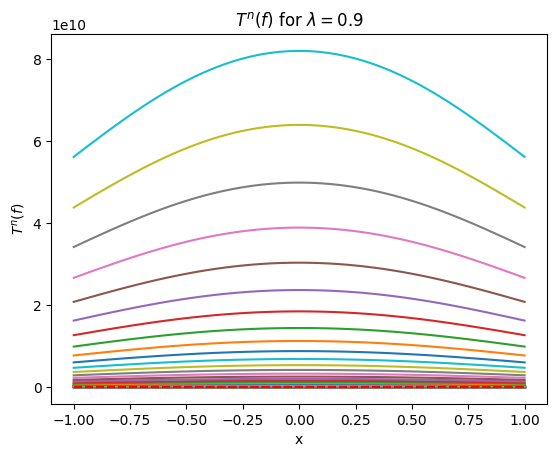

Max iterations reached without full convergence.


In [51]:
g = lambda x: np.sin(2*np.pi*x)
K = lambda x, y: 1 / (1 + (x-y)**2 )
f0 = lambda x: np.exp(x)

x_grid, solution = contraction_solve(g, -1, 1, lamb = 0.9, f0_func = f0)